# FDR Benchmark: Entropy Similarity vs Reverse Score vs Ion Ratio

Extends the Yuanyue Li leave-one-out FDR benchmark (`yuanyue_fdr.ipynb`) to compare three scoring metrics:

| Metric | Definition | Range |
|---|---|---|
| **Entropy similarity** | Symmetric spectral entropy similarity (ms_entropy) | [0, 1] |
| **Reverse score** | Fraction of query intensity explained by library peaks | [0, 1] |
| **Ion ratio (ratio_profile)** | Cosine similarity of matched peak intensity vectors | [0, 1] |

**Protocol:** Same as Li et al. (Nature Methods 2021):
1. 20,000 NIST23 [M+H]+ spectra, leave-one-out
2. 10 ppm precursor window, 0.05 Da MS2 tolerance
3. FDR = FP / (FP + TP) at each score threshold
4. Stratified by spectral entropy

**Data:** `nist_protonated_sampled.msp`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ms_entropy as me
from bisect import bisect_left, bisect_right
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

METRICS = ['entropy_sim', 'forward_score', 'ratio_profile']
METRIC_LABELS = {
    'entropy_sim': 'Entropy similarity',
    'forward_score': 'Reverse score',
    'ratio_profile': 'Ion ratio (cosine)',
}
METRIC_COLORS = {
    'entropy_sim': 'tab:blue',
    'forward_score': 'tab:orange',
    'ratio_profile': 'tab:green',
}

## 1. Parse MSP & compute spectral entropy

In [2]:
MSP_PATH = '../data/reference_db/nist_protonated_sampled.msp'
PPM_TOL = 10
MS2_TOL = 0.05  # Da, matching Yuanyue's methods

def parse_msp(path):
    """Parse MSP file into list of spectrum dicts."""
    spectra = []
    current = {}
    peaks = []

    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current and peaks:
                    arr = np.array(peaks, dtype=np.float32)
                    base_peak = arr[:, 1].max()
                    arr = arr[arr[:, 1] >= 0.01 * base_peak]
                    if len(arr) > 0:
                        current['peaks'] = arr
                        spectra.append(current)
                current = {}
                peaks = []
                continue
            if ':' in line and not line[0].isdigit():
                key, val = line.split(':', 1)
                key = key.strip().lower()
                val = val.strip()
                if key == 'name':
                    current['name'] = val
                elif key == 'precursormz':
                    current['precursor_mz'] = float(val)
                elif key == 'inchikey':
                    current['inchikey14'] = val[:14]
                elif key == 'num peaks':
                    current['num_peaks'] = int(val)
            elif line[0].isdigit():
                parts = line.split()
                if len(parts) >= 2:
                    peaks.append([float(parts[0]), float(parts[1])])

    if current and peaks:
        arr = np.array(peaks, dtype=np.float32)
        base_peak = arr[:, 1].max()
        arr = arr[arr[:, 1] >= 0.01 * base_peak]
        if len(arr) > 0:
            current['peaks'] = arr
            spectra.append(current)

    return spectra

spectra = parse_msp(MSP_PATH)
print(f'Parsed {len(spectra):,} spectra')
print(f'Unique compounds (InChIKey14): {len(set(s["inchikey14"] for s in spectra)):,}')

Parsed 20,000 spectra
Unique compounds (InChIKey14): 15,637


In [3]:
# Compute spectral entropy and sort by precursor m/z
for s in spectra:
    s['entropy'] = float(me.calculate_spectral_entropy(
        s['peaks'], clean_spectrum=True, min_ms2_difference_in_da=MS2_TOL
    ))

# Sort by precursor m/z for binary search in leave-one-out
sorted_idx = np.argsort([s['precursor_mz'] for s in spectra])
spectra_sorted = [spectra[i] for i in sorted_idx]
mz_array = np.array([s['precursor_mz'] for s in spectra_sorted])

# Pre-clean spectra: remove precursor ion
for s in spectra_sorted:
    mask = np.abs(s['peaks'][:, 0] - s['precursor_mz']) > MS2_TOL
    s['peaks_clean'] = s['peaks'][mask]

# Pre-compute entropy-weighted & normalized spectra for forward/reverse/ion-ratio
for s in spectra_sorted:
    p = s['peaks_clean']
    if len(p) > 0:
        cleaned = me.clean_spectrum(p, min_ms2_difference_in_da=MS2_TOL)
        if len(cleaned) > 0:
            weighted = np.array(me.apply_weight_to_intensity(cleaned), dtype=np.float64)
            s['w_mz'] = weighted[:, 0]
            s['w_int'] = weighted[:, 1]
            total = s['w_int'].sum()
            s['w_int_norm'] = s['w_int'] / total if total > 0 else s['w_int']
        else:
            s['w_mz'] = np.empty(0)
            s['w_int'] = np.empty(0)
            s['w_int_norm'] = np.empty(0)
    else:
        s['w_mz'] = np.empty(0)
        s['w_int'] = np.empty(0)
        s['w_int_norm'] = np.empty(0)

entropies = np.array([s['entropy'] for s in spectra_sorted])
print(f'Spectral entropy -- min: {entropies.min():.2f}, median: {np.median(entropies):.2f}, max: {entropies.max():.2f}')
for lo, hi, label in [(0,1,'S=0-1'), (1,2,'S=1-2'), (2,3,'S=2-3'), (3,99,'S>3')]:
    n = ((entropies >= lo) & (entropies < hi)).sum()
    print(f'  {label}: {n:,} ({100*n/len(entropies):.1f}%)')
print(f'\nPre-weighted spectra ready: {sum(1 for s in spectra_sorted if len(s["w_mz"]) > 0):,}')

Spectral entropy -- min: -0.00, median: 1.51, max: 5.59
  S=0-1: 6,191 (31.0%)
  S=1-2: 6,782 (33.9%)
  S=2-3: 4,706 (23.5%)
  S>3: 2,321 (11.6%)

Pre-weighted spectra ready: 19,993


## 2. Leave-one-out search with multi-metric tracking

For each query, find all candidates in 10 ppm window. For each (query, candidate) pair compute:
- **Entropy similarity** via `ms_entropy` (symmetric, entropy-weighted)
- **Forward score**: fraction of library (weighted) intensity matched by query
- **Reverse score**: fraction of query (weighted) intensity matched by library. Unmatched query peaks completely ignored. 
- **Ion ratio (ratio_profile)**: cosine similarity of matched peak intensity vectors

Track the best correct (same IK14) and best wrong (different IK14) score for each metric independently.

In [4]:
def match_peaks(q_mz, q_int_norm, q_int_raw,
                l_mz, l_int_norm, l_int_raw, tol_da):
    """Fast peak matching: returns forward, reverse, ratio_profile, n_matched.
    
    forward  = sum of matched library intensity (normalized)
    reverse  = sum of matched query intensity (normalized)
    ratio_profile = cosine of matched raw intensity vectors
    """
    if len(q_mz) == 0 or len(l_mz) == 0:
        return 0.0, 0.0, np.nan, 0

    matched_l = 0.0
    matched_q = 0.0
    q_raw_matched = []
    l_raw_matched = []
    used_q = np.zeros(len(q_mz), dtype=bool)

    for j in range(len(l_mz)):
        diffs = np.abs(q_mz - l_mz[j])
        candidates = np.where((diffs <= tol_da) & ~used_q)[0]
        if len(candidates) > 0:
            best = candidates[np.argmin(diffs[candidates])]
            matched_l += l_int_norm[j]
            matched_q += q_int_norm[best]
            q_raw_matched.append(q_int_raw[best])
            l_raw_matched.append(l_int_raw[j])
            used_q[best] = True

    n_matched = len(q_raw_matched)

    if n_matched >= 2:
        q_arr = np.array(q_raw_matched)
        l_arr = np.array(l_raw_matched)
        q_norm = q_arr / np.linalg.norm(q_arr)
        l_norm = l_arr / np.linalg.norm(l_arr)
        ratio_profile = float(np.dot(q_norm, l_norm))
    else:
        ratio_profile = np.nan

    return matched_l, matched_q, ratio_profile, n_matched

In [5]:
n = len(spectra_sorted)

# For each query: best correct & best wrong for each metric (including combined)
ALL_TRACK = METRICS + ['combined']
results = []

for qi in range(n):
    query = spectra_sorted[qi]
    qmz = query['precursor_mz']
    qik = query['inchikey14']
    qpeaks = query['peaks_clean']

    if len(qpeaks) == 0 or len(query['w_mz']) == 0:
        continue

    # 10 ppm precursor window
    mz_lo = qmz * (1 - PPM_TOL / 1e6)
    mz_hi = qmz * (1 + PPM_TOL / 1e6)
    lo_idx = bisect_left(mz_array, mz_lo)
    hi_idx = bisect_right(mz_array, mz_hi)

    best_correct = {m: -1.0 for m in ALL_TRACK}
    best_wrong   = {m: -1.0 for m in ALL_TRACK}
    has_correct_candidate = False
    n_candidates = 0

    for ci in range(lo_idx, hi_idx):
        if ci == qi:
            continue
        cand = spectra_sorted[ci]
        if len(cand['peaks_clean']) == 0 or len(cand['w_mz']) == 0:
            continue
        n_candidates += 1

        # Entropy similarity (via ms_entropy)
        esim = me.calculate_entropy_similarity(
            qpeaks, cand['peaks_clean'],
            ms2_tolerance_in_da=MS2_TOL, clean_spectra=True
        )

        # Forward / reverse / ion ratio (from pre-weighted spectra)
        fwd, rev, ratio, n_matched = match_peaks(
            query['w_mz'], query['w_int_norm'], query['w_int'],
            cand['w_mz'], cand['w_int_norm'], cand['w_int'],
            MS2_TOL
        )

        # Combined: geometric mean of available scores
        if not np.isnan(ratio) and ratio > 0 and esim > 0 and rev > 0:
            combined = (esim * rev * ratio) ** (1/3)
        elif esim > 0 and rev > 0:
            combined = (esim * rev) ** (1/2)
        else:
            combined = esim

        scores = {
            'entropy_sim': esim,
            'forward_score': rev,
            'ratio_profile': ratio if not np.isnan(ratio) else -1.0,
            'combined': combined,
        }

        is_correct = cand['inchikey14'] == qik
        if is_correct:
            has_correct_candidate = True

        target = best_correct if is_correct else best_wrong
        for m in ALL_TRACK:
            target[m] = max(target[m], scores[m])

    results.append({
        'entropy': query['entropy'],
        'has_correct_candidate': has_correct_candidate,
        'n_candidates': n_candidates,
        **{f'best_correct_{m}': best_correct[m] for m in ALL_TRACK},
        **{f'best_wrong_{m}': best_wrong[m] for m in ALL_TRACK},
    })

    if (qi + 1) % 2000 == 0:
        print(f'  {qi+1:,}/{n:,} done...')

print(f'Finished: {len(results):,} queries')
df = pd.DataFrame(results)

  2,000/20,000 done...


  4,000/20,000 done...


  6,000/20,000 done...


  8,000/20,000 done...


  10,000/20,000 done...


  12,000/20,000 done...


  14,000/20,000 done...


  16,000/20,000 done...


  18,000/20,000 done...


  20,000/20,000 done...
Finished: 19,993 queries


In [6]:
# Sanity checks
print(f'Queries with correct candidate: {df["has_correct_candidate"].sum():,} / {len(df):,} '
      f'({100*df["has_correct_candidate"].mean():.1f}%)')
print(f'Median candidates per query: {df["n_candidates"].median():.0f}')
print()

for m in METRICS:
    bc = df[f'best_correct_{m}']
    bw = df[f'best_wrong_{m}']
    has_c = bc >= 0
    has_w = bw >= 0
    print(f'{METRIC_LABELS[m]}:')
    print(f'  Correct: {has_c.sum():,} queries, mean={bc[has_c].mean():.3f}, median={bc[has_c].median():.3f}')
    print(f'  Wrong:   {has_w.sum():,} queries, mean={bw[has_w].mean():.3f}, median={bw[has_w].median():.3f}')

Queries with correct candidate: 8,017 / 19,993 (40.1%)
Median candidates per query: 2

Entropy similarity:
  Correct: 8,017 queries, mean=0.590, median=0.662
  Wrong:   13,400 queries, mean=0.293, median=0.206
Reverse score:
  Correct: 8,017 queries, mean=0.672, median=0.796
  Wrong:   13,400 queries, mean=0.412, median=0.358
Ion ratio (cosine):
  Correct: 6,284 queries, mean=0.819, median=0.908
  Wrong:   8,039 queries, mean=0.801, median=0.888


## 3. FDR curves — all metrics compared

FDR at threshold $t$ for metric $M$:

$$\text{TP} = \sum \mathbb{1}[\text{best\_correct}_M \ge t]$$
$$\text{FP} = \sum \mathbb{1}[\text{best\_wrong}_M \ge t \;\wedge\; \text{best\_correct}_M < t]$$
$$\text{FDR} = \frac{FP}{FP + TP}$$

In [7]:
thresholds = np.linspace(0, 1, 201)

def compute_fdr_curve(df_sub, metric, thresholds):
    bc = df_sub[f'best_correct_{metric}'].values
    bw = df_sub[f'best_wrong_{metric}'].values
    fdrs = []
    for t in thresholds:
        tp = np.sum(bc >= t)
        fp = np.sum((bw >= t) & (bc < t))
        fdr = fp / (fp + tp) if (fp + tp) > 0 else 0.0
        fdrs.append(fdr)
    return np.array(fdrs)

def compute_tpr_curve(df_sub, metric, thresholds):
    bc = df_sub[f'best_correct_{metric}'].values
    n_with_correct = (bc >= 0).sum()
    if n_with_correct == 0:
        return np.zeros_like(thresholds)
    return np.array([np.sum(bc >= t) / n_with_correct for t in thresholds])

# Compute FDR for all metrics
fdr_curves = {}
tpr_curves = {}
for m in METRICS:
    fdr_curves[m] = compute_fdr_curve(df, m, thresholds)
    tpr_curves[m] = compute_tpr_curve(df, m, thresholds)

# Print key thresholds
print(f'{"Metric":<25s} {"FDR@0.7":>8} {"FDR@0.8":>8} {"FDR@0.9":>8} {"FDR@0.95":>8}')
print('-' * 62)
for m in METRICS:
    vals = [fdr_curves[m][np.argmin(np.abs(thresholds - t))] for t in [0.7, 0.8, 0.9, 0.95]]
    print(f'{METRIC_LABELS[m]:<25s} {vals[0]:>8.3f} {vals[1]:>8.3f} {vals[2]:>8.3f} {vals[3]:>8.3f}')

Metric                     FDR@0.7  FDR@0.8  FDR@0.9 FDR@0.95
--------------------------------------------------------------
Entropy similarity           0.270    0.229    0.184    0.191
Reverse score                0.374    0.355    0.333    0.324
Ion ratio (cosine)           0.478    0.486    0.492    0.500


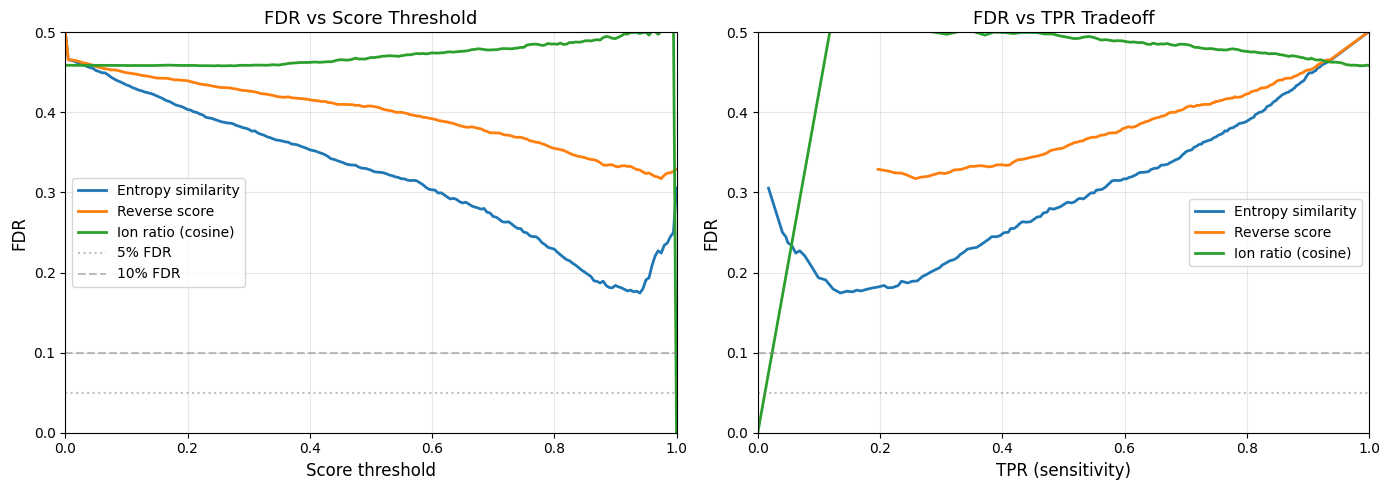

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: FDR vs threshold
ax = axes[0]
for m in METRICS:
    ax.plot(thresholds, fdr_curves[m], color=METRIC_COLORS[m], linewidth=2,
            label=METRIC_LABELS[m])
ax.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5, label='5% FDR')
ax.axhline(y=0.10, color='gray', linestyle='--', alpha=0.5, label='10% FDR')
ax.set_xlabel('Score threshold', fontsize=12)
ax.set_ylabel('FDR', fontsize=12)
ax.set_title('FDR vs Score Threshold', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 0.5)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: FDR vs TPR (tradeoff)
ax = axes[1]
for m in METRICS:
    ax.plot(tpr_curves[m], fdr_curves[m], color=METRIC_COLORS[m], linewidth=2,
            label=METRIC_LABELS[m])
ax.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=0.10, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('TPR (sensitivity)', fontsize=12)
ax.set_ylabel('FDR', fontsize=12)
ax.set_title('FDR vs TPR Tradeoff', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 0.5)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fdr_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. FDR stratified by spectral entropy

Key question: do reverse score and ion ratio degrade for low-entropy spectra the same way entropy similarity does?

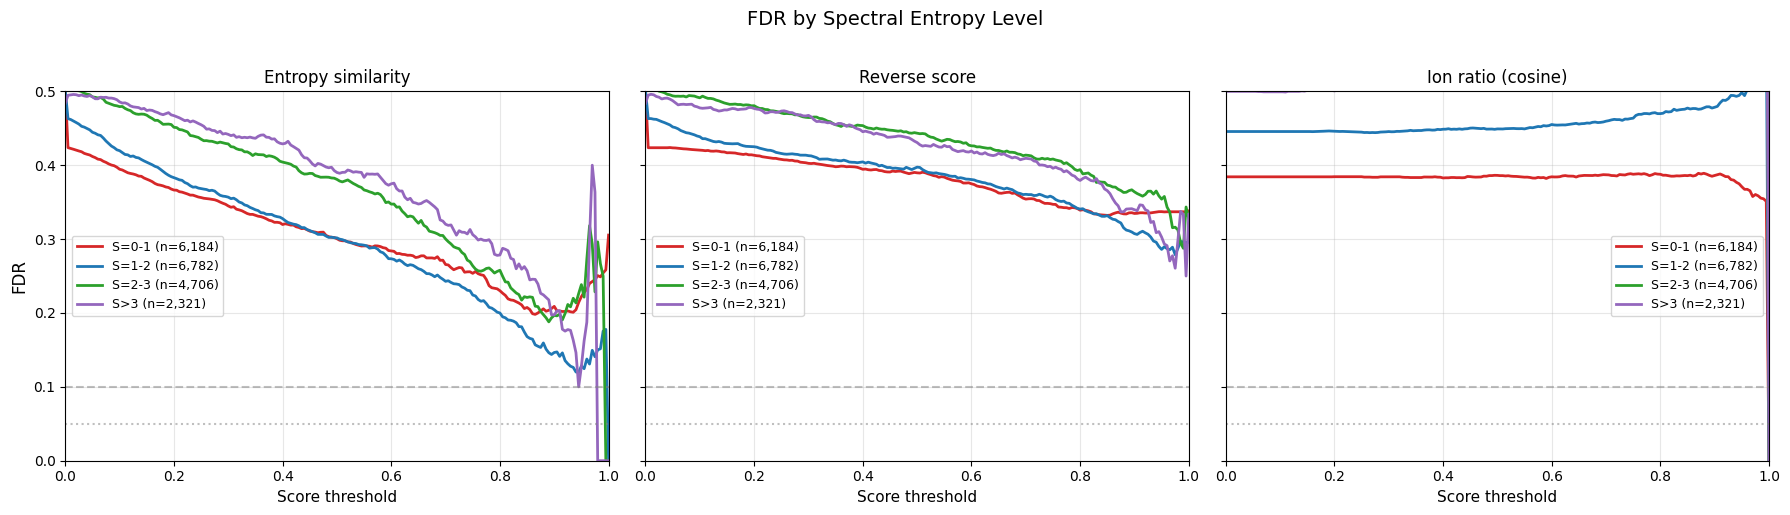

In [9]:
entropy_bins = [(0, 1, 'S=0-1'), (1, 2, 'S=1-2'), (2, 3, 'S=2-3'), (3, 99, 'S>3')]
bin_colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:purple']

fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 5), sharey=True)

for ax, m in zip(axes, METRICS):
    for (lo, hi, label), color in zip(entropy_bins, bin_colors):
        mask = (df['entropy'] >= lo) & (df['entropy'] < hi)
        subset = df[mask]
        if len(subset) < 10:
            continue
        fdr = compute_fdr_curve(subset, m, thresholds)
        ax.plot(thresholds, fdr, color=color, linewidth=2, label=f'{label} (n={len(subset):,})')
    ax.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(y=0.10, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Score threshold', fontsize=11)
    ax.set_title(METRIC_LABELS[m], fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('FDR', fontsize=12)
plt.suptitle('FDR by Spectral Entropy Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fdr_benchmark_by_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Threshold needed for target FDR (per metric, per entropy bin)

In [ ]:
# may be disregarded as it's just printing out thresholds for different FDR levels, but keeping here for completeness
def find_threshold_for_fdr(fdr_curve, thresholds, target_fdr):
    """Lowest threshold achieving <= target FDR (scanning high to low)."""
    for i in range(len(thresholds) - 1, -1, -1):
        if fdr_curve[i] <= target_fdr:
            return thresholds[i]
    return None

for target in [0.01, 0.05, 0.10]:
    print(f'\n=== Threshold for FDR <= {target:.0%} ===')
    header = f'{"Entropy bin":<12}'
    for m in METRICS:
        header += f'  {METRIC_LABELS[m]:>22}'
    print(header)
    print('-' * (12 + 24 * len(METRICS)))

    for (lo, hi, label) in entropy_bins:
        mask = (df['entropy'] >= lo) & (df['entropy'] < hi)
        subset = df[mask]
        if len(subset) < 10:
            continue
        row = f'{label:<12}'
        for m in METRICS:
            fdr = compute_fdr_curve(subset, m, thresholds)
            t = find_threshold_for_fdr(fdr, thresholds, target)
            row += f'  {t if t is not None else "N/A":>22}'
        print(row)

    # Overall
    row = f'{"Overall":<12}'
    for m in METRICS:
        t = find_threshold_for_fdr(fdr_curves[m], thresholds, target)
        row += f'  {t if t is not None else "N/A":>22}'
    print(row)


=== Threshold for FDR <= 1% ===
Entropy bin       Entropy similarity           Reverse score      Ion ratio (cosine)
------------------------------------------------------------------------------------
S=0-1                            N/A                     N/A                     1.0
S=1-2                            1.0                     N/A                     1.0
S=2-3                            1.0                     N/A                     1.0
S>3                              1.0                     N/A                     1.0
Overall                          N/A                     N/A                     1.0

=== Threshold for FDR <= 5% ===
Entropy bin       Entropy similarity           Reverse score      Ion ratio (cosine)
------------------------------------------------------------------------------------
S=0-1                            N/A                     N/A                     1.0
S=1-2                            1.0                     N/A                     1.0

S=0-1                            N/A                     N/A                     1.0
S=1-2                            1.0                     N/A                     1.0
S=2-3                            1.0                     N/A                     1.0
S>3                              1.0                     N/A                     1.0
Overall                          N/A                     N/A                     1.0


## 6. ROC comparison

For each query with candidates, the "call" is the best overall match. Label = 1 if the best match (by that metric) is the correct compound.

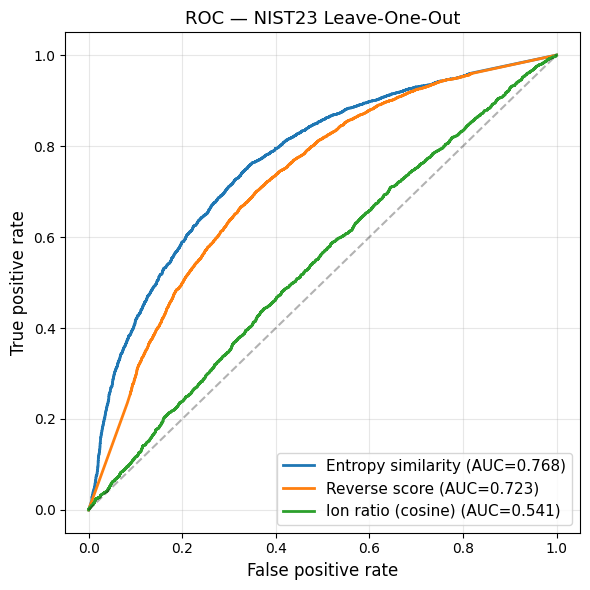

In [11]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(6, 6))

for m in METRICS:
    # Query must have at least one candidate
    bc = df[f'best_correct_{m}']
    bw = df[f'best_wrong_{m}']
    has_any = (bc >= 0) | (bw >= 0)
    sub = df[has_any].copy()

    # Best overall score and whether the best is correct
    sub['best_score'] = np.maximum(sub[f'best_correct_{m}'], sub[f'best_wrong_{m}'])
    sub['label'] = (sub[f'best_correct_{m}'] >= sub[f'best_wrong_{m}']).astype(int)

    # Skip entries where ratio_profile was NaN for both (set to -1)
    valid = sub['best_score'] > -0.5
    sub = sub[valid]

    fpr, tpr, _ = roc_curve(sub['label'], sub['best_score'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=METRIC_COLORS[m], linewidth=2,
            label=f'{METRIC_LABELS[m]} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False positive rate', fontsize=12)
ax.set_ylabel('True positive rate', fontsize=12)
ax.set_title('ROC — NIST23 Leave-One-Out', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fdr_benchmark_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. TP / FP counts at common thresholds

In [12]:
for m in METRICS:
    print(f'\n--- {METRIC_LABELS[m]} ---')
    print(f'{"Threshold":>10} {"TP":>8} {"FP":>8} {"FDR":>8} {"TPR":>8}')
    print('-' * 45)

    bc = df[f'best_correct_{m}'].values
    bw = df[f'best_wrong_{m}'].values
    n_with_correct = df['has_correct_candidate'].sum()

    for t in [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]:
        tp = np.sum(bc >= t)
        fp = np.sum((bw >= t) & (bc < t))
        fdr = fp / (fp + tp) if (fp + tp) > 0 else 0.0
        tpr = tp / n_with_correct if n_with_correct > 0 else 0.0
        print(f'{t:>10.2f} {tp:>8} {fp:>8} {fdr:>8.4f} {tpr:>8.4f}')


--- Entropy similarity ---
 Threshold       TP       FP      FDR      TPR
---------------------------------------------
      0.50     5147     2512   0.3280   0.6420
      0.60     4478     1950   0.3034   0.5586
      0.70     3709     1372   0.2700   0.4626
      0.75     3287     1098   0.2504   0.4100
      0.80     2750      818   0.2293   0.3430
      0.85     2265      568   0.2005   0.2825
      0.90     1655      373   0.1839   0.2064
      0.95      891      210   0.1907   0.1111

--- Reverse score ---
 Threshold       TP       FP      FDR      TPR
---------------------------------------------
      0.50     5659     3900   0.4080   0.7059
      0.60     5197     3353   0.3922   0.6482
      0.70     4671     2796   0.3744   0.5826
      0.75     4345     2529   0.3679   0.5420
      0.80     3982     2192   0.3550   0.4967
      0.85     3564     1865   0.3435   0.4446
      0.90     3086     1539   0.3328   0.3849
      0.95     2458     1176   0.3236   0.3066

--- Ion ra

## 8. Score distributions: correct vs wrong (per metric)

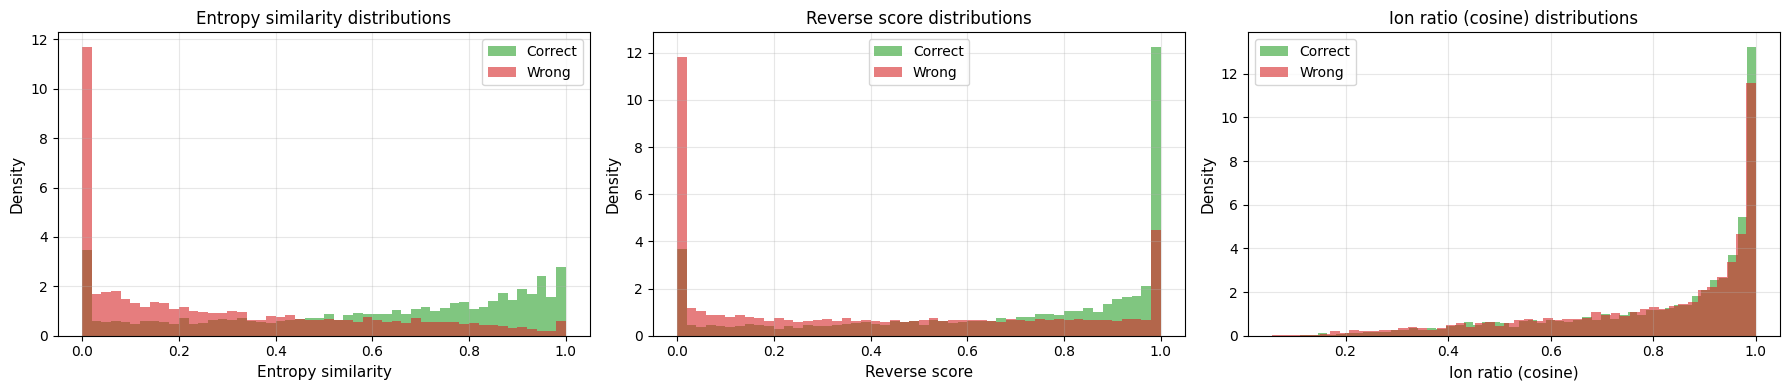

In [13]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 4))

for ax, m in zip(axes, METRICS):
    bc = df[f'best_correct_{m}']
    bw = df[f'best_wrong_{m}']
    has_c = bc >= 0
    has_w = bw >= 0
    ax.hist(bc[has_c], bins=50, alpha=0.6, density=True, color='tab:green', label='Correct')
    ax.hist(bw[has_w], bins=50, alpha=0.6, density=True, color='tab:red', label='Wrong')
    ax.set_xlabel(METRIC_LABELS[m], fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{METRIC_LABELS[m]} distributions', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fdr_benchmark_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Metric correlation & complementarity

Are the metrics redundant or do they capture different information?

Correlation matrix (n=6,284 queries with all metrics):
                    Entropy similarity  Reverse score  Ion ratio (cosine)
Entropy similarity               1.000          0.848               0.568
Reverse score                    0.848          1.000               0.352
Ion ratio (cosine)               0.568          0.352               1.000



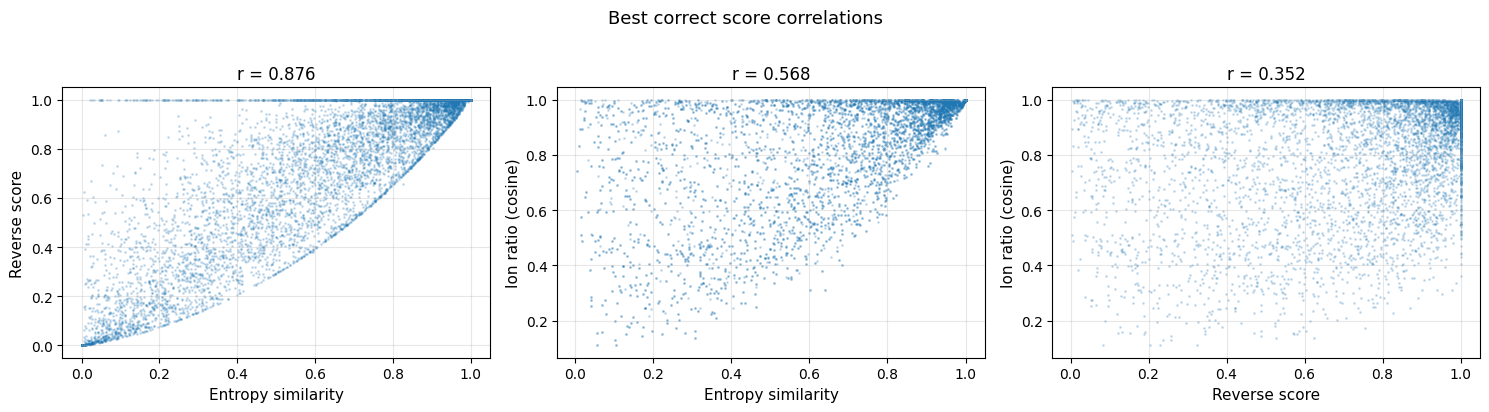

In [14]:
# Pairwise correlations among best-correct scores (for queries with correct candidate)
has_correct = df['has_correct_candidate']
corr_data = {}
for m in METRICS:
    corr_data[METRIC_LABELS[m]] = df.loc[has_correct, f'best_correct_{m}']

corr_df = pd.DataFrame(corr_data)
# Filter out ratio_profile = -1 (NaN placeholders)
valid = (corr_df > -0.5).all(axis=1)
corr_df = corr_df[valid]

print(f'Correlation matrix (n={len(corr_df):,} queries with all metrics):')
print(corr_df.corr().round(3))
print()

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    ('entropy_sim', 'forward_score'),
    ('entropy_sim', 'ratio_profile'),
    ('forward_score', 'ratio_profile'),
]
for ax, (m1, m2) in zip(axes, pairs):
    x = df.loc[has_correct, f'best_correct_{m1}']
    y = df.loc[has_correct, f'best_correct_{m2}']
    valid = (x >= 0) & (y >= 0)
    ax.scatter(x[valid], y[valid], s=1, alpha=0.2)
    r = np.corrcoef(x[valid], y[valid])[0, 1]
    ax.set_xlabel(METRIC_LABELS[m1], fontsize=11)
    ax.set_ylabel(METRIC_LABELS[m2], fontsize=11)
    ax.set_title(f'r = {r:.3f}', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.suptitle('Best correct score correlations', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Final comparison: all metrics including combined (geometric mean)

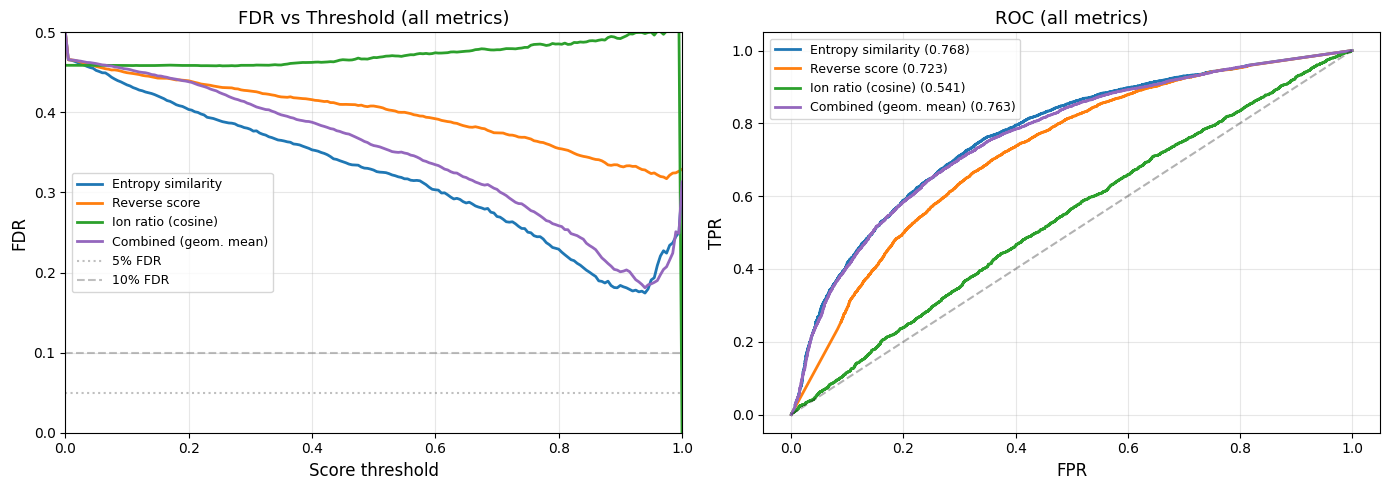

In [15]:
# Final comparison: all 4 metrics including combined
ALL_METRICS = METRICS + ['combined']
ALL_LABELS = {**METRIC_LABELS, 'combined': 'Combined (geom. mean)'}
ALL_COLORS = {**METRIC_COLORS, 'combined': 'tab:purple'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FDR curves
ax = axes[0]
for m in ALL_METRICS:
    fdr = compute_fdr_curve(df, m, thresholds)
    ax.plot(thresholds, fdr, color=ALL_COLORS[m], linewidth=2, label=ALL_LABELS[m])
ax.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5, label='5% FDR')
ax.axhline(y=0.10, color='gray', linestyle='--', alpha=0.5, label='10% FDR')
ax.set_xlabel('Score threshold', fontsize=12)
ax.set_ylabel('FDR', fontsize=12)
ax.set_title('FDR vs Threshold (all metrics)', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 0.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ROC curves
ax = axes[1]
for m in ALL_METRICS:
    bc = df[f'best_correct_{m}']
    bw = df[f'best_wrong_{m}']
    has_any = (bc >= 0) | (bw >= 0)
    sub = df[has_any].copy()
    sub['best_score'] = np.maximum(sub[f'best_correct_{m}'], sub[f'best_wrong_{m}'])
    sub['label'] = (sub[f'best_correct_{m}'] >= sub[f'best_wrong_{m}']).astype(int)
    valid = sub['best_score'] > -0.5
    sub = sub[valid]
    fpr, tpr, _ = roc_curve(sub['label'], sub['best_score'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=ALL_COLORS[m], linewidth=2,
            label=f'{ALL_LABELS[m]} ({roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('FPR', fontsize=12)
ax.set_ylabel('TPR', fontsize=12)
ax.set_title('ROC (all metrics)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fdr_benchmark_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save results

In [16]:
import os
out_dir = '../results/fdr_benchmark_scores'
os.makedirs(out_dir, exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# Per-query results
df.to_csv(f'{out_dir}/query_results.csv', index=False)

# FDR curves for all metrics
fdr_out = pd.DataFrame({'threshold': thresholds})
for m in ALL_METRICS:
    fdr_out[f'fdr_{m}'] = compute_fdr_curve(df, m, thresholds)
    fdr_out[f'tpr_{m}'] = compute_tpr_curve(df, m, thresholds)
fdr_out.to_csv(f'{out_dir}/fdr_curves.csv', index=False)

print(f'Saved to {out_dir}/')
print(f'  query_results.csv: {len(df):,} queries x {len(df.columns)} cols')
print(f'  fdr_curves.csv: {len(fdr_out)} thresholds x {len(ALL_METRICS)} metrics')

Saved to ../results/fdr_benchmark_scores/
  query_results.csv: 19,993 queries x 11 cols
  fdr_curves.csv: 201 thresholds x 4 metrics
